In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure3/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


In [4]:
adata_new_HC_v3=sc.read('human_HC_final.h5ad')
adata_new_HC_v3

AnnData object with n_obs × n_vars = 203 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final', 'cell_type_final_v2', 'scANVI_res2.0', 'cell_type_final_v4'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', '

In [5]:
import scvelo as scv

In [7]:
adata=sc.read('human_cochlea_annotation.h5ad')

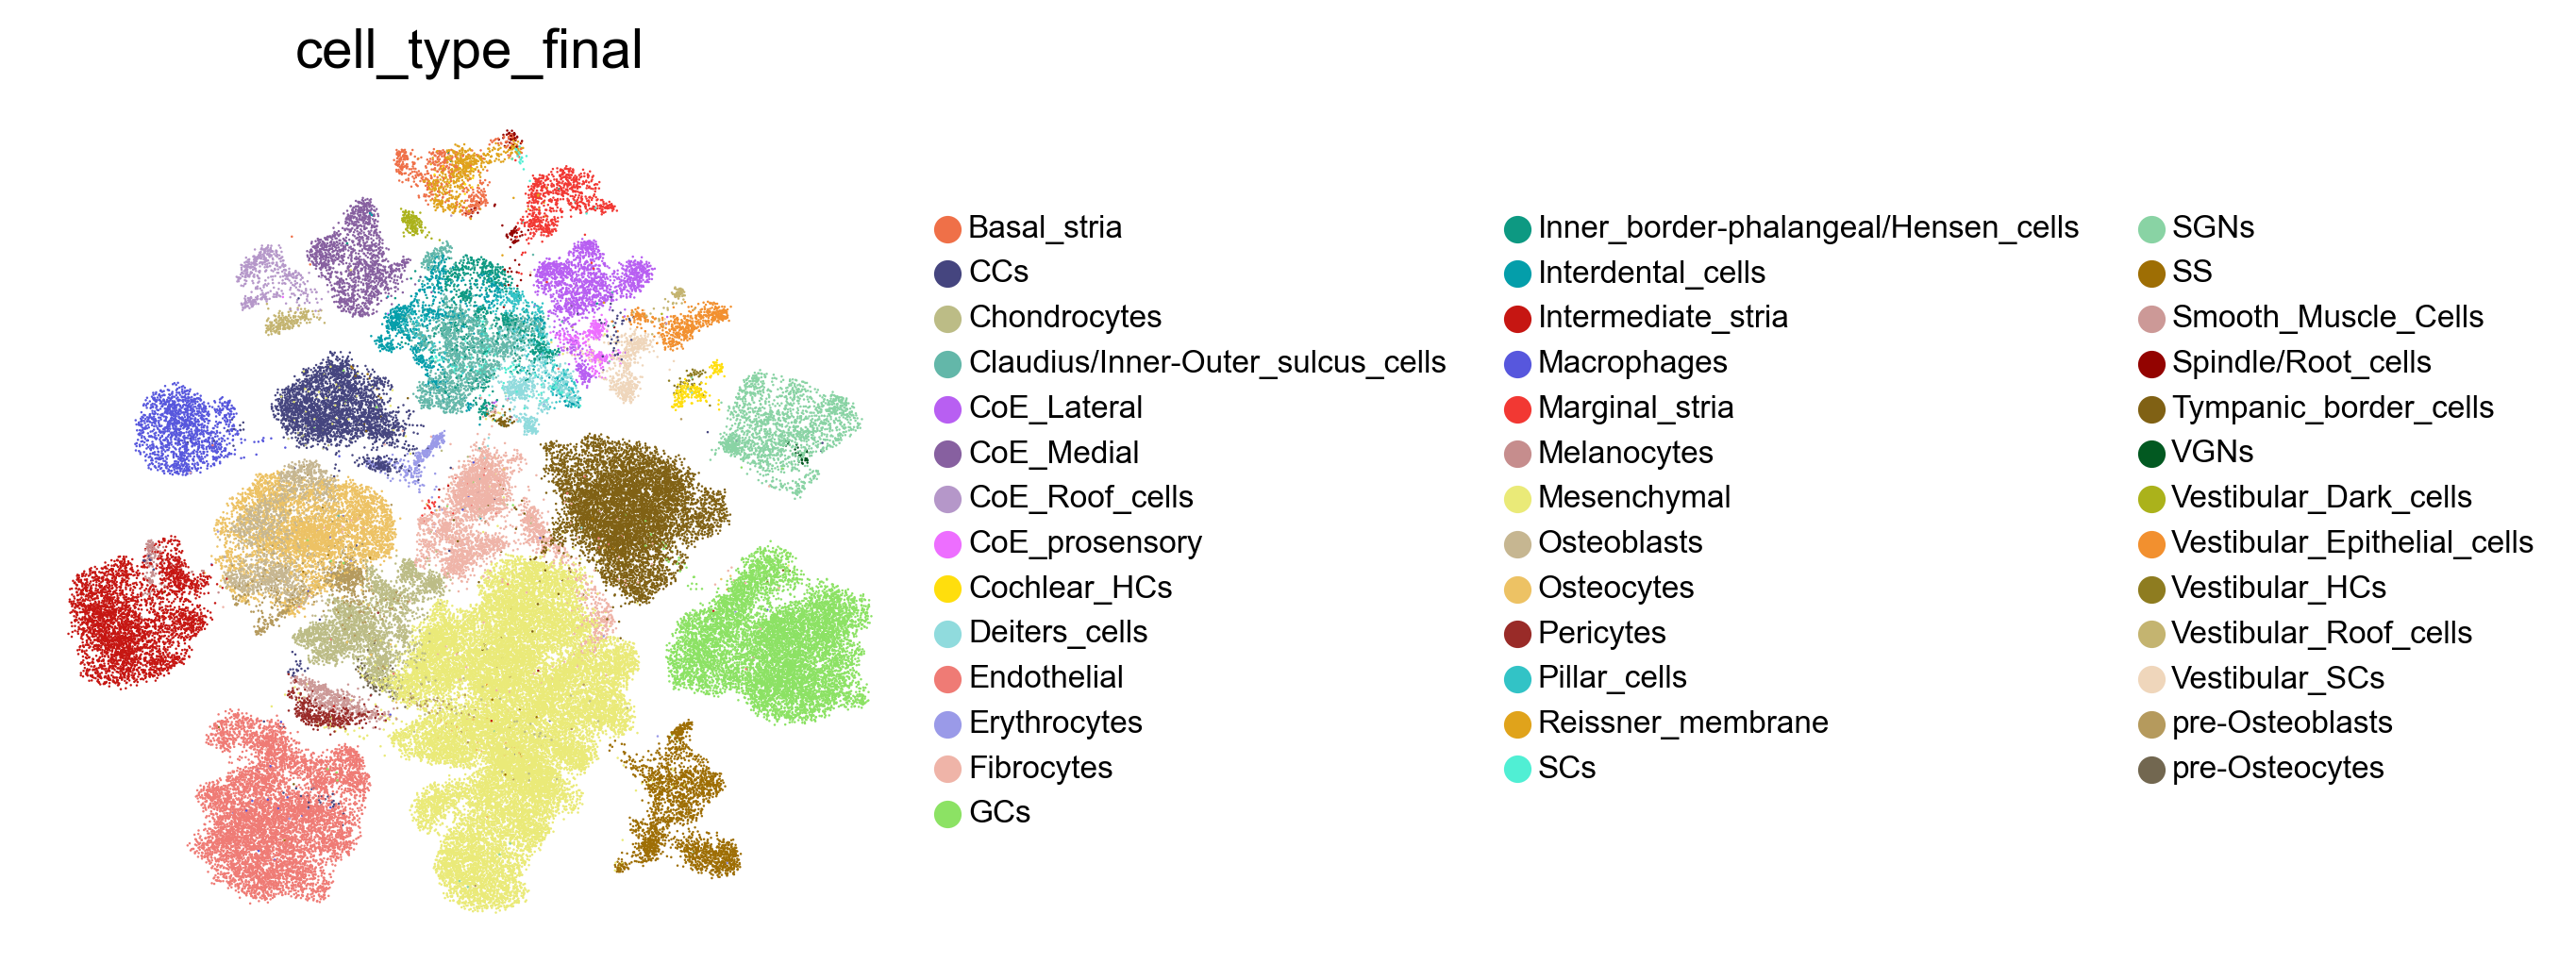

In [11]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata,legend_fontsize=8, save='_cochlea.pdf',
    color="cell_type_final",)

#### FIGURE 3a

In [8]:
adata.obs["sel1"]=(adata.obs.cell_type_final=='Cochlear_HCs').astype(str)

In [14]:
from matplotlib.patches import ConnectionPatch

<Axes: >

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

Text(0.5, 0, '')

Text(0, 0.5, '')

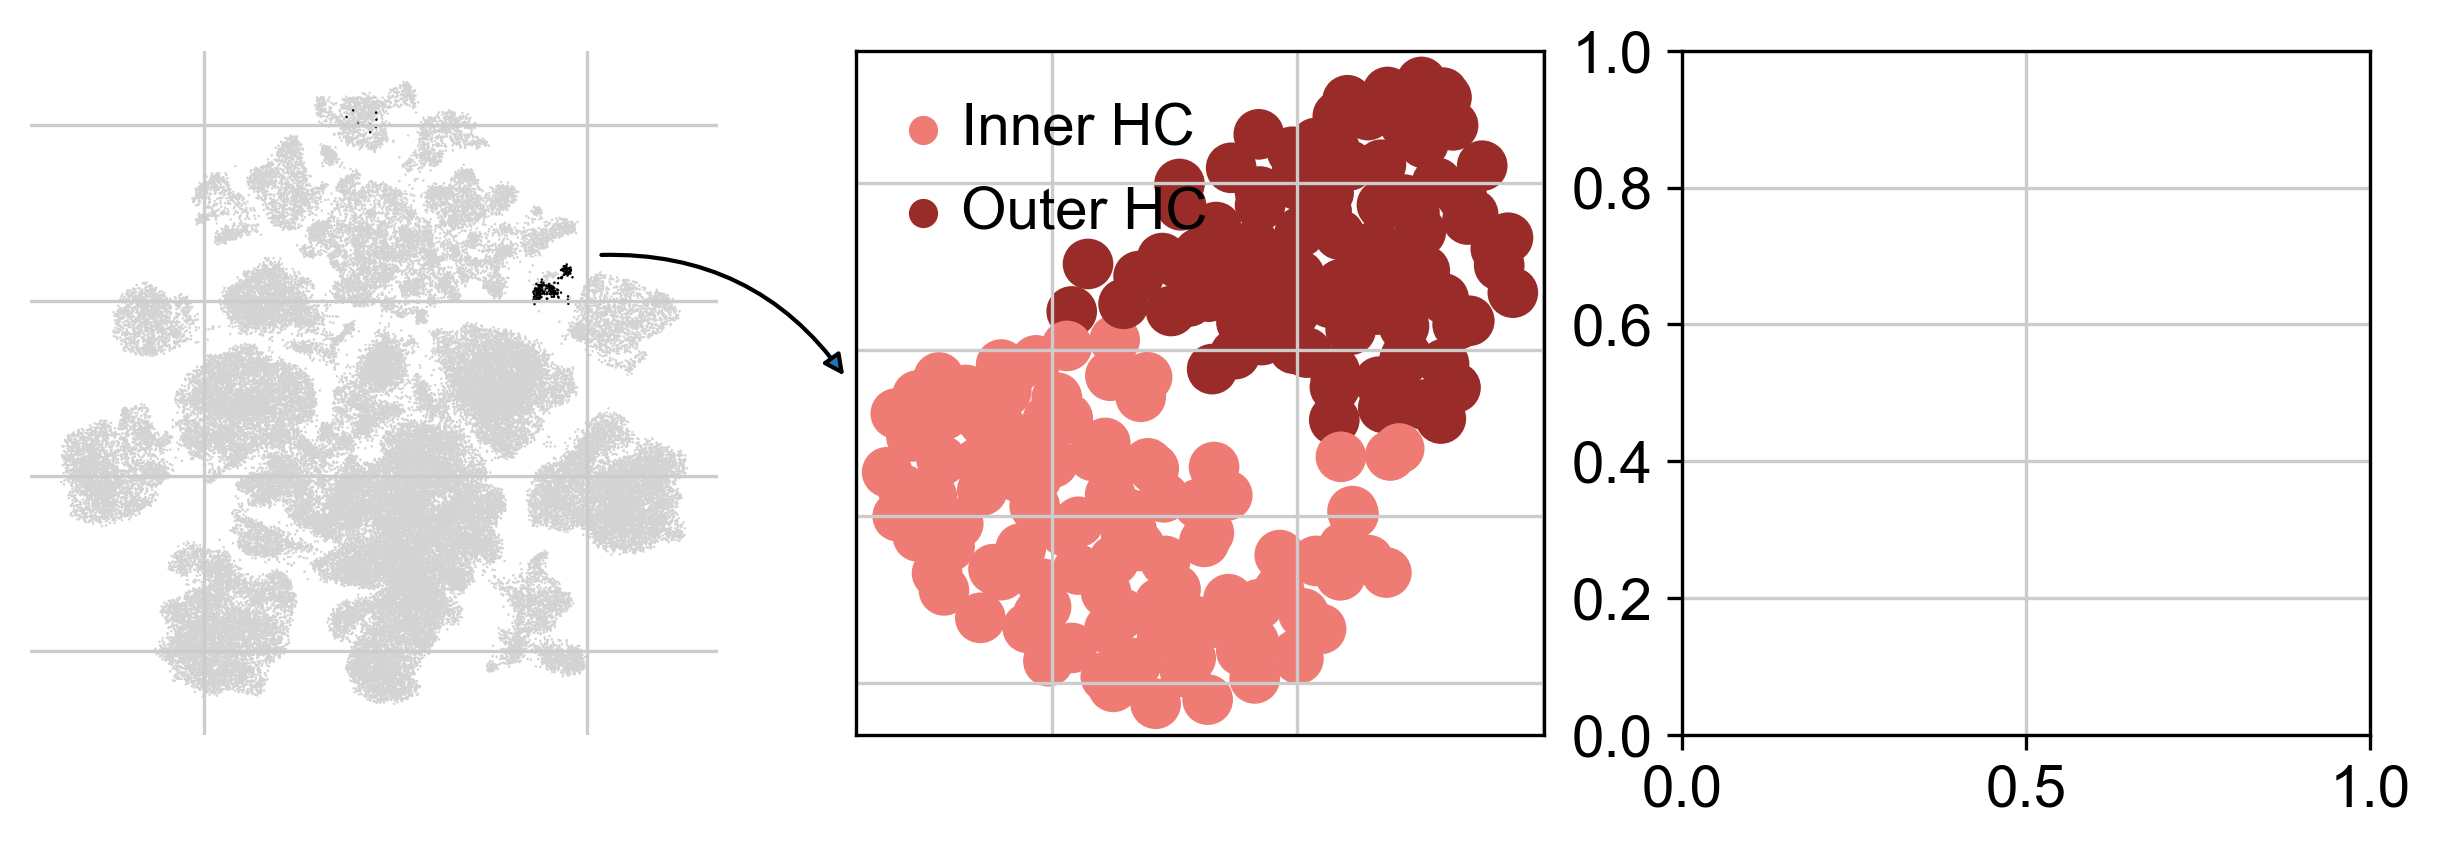

In [15]:
fig,axs=plt.subplots(1,3,figsize=(10,3))
scv.pl.umap(adata,color="sel1",ax=axs[0],show=False,
                  palette=["lightgrey","k"],frameon=False,legend_loc="none",title="")
scv.pl.umap(adata_new_HC_v3,color="cell_type_final_v4",title="",frameon=True,ax=axs[1],legend_loc="none",
            show=False,palette=["#ef7b75","#992b28"])
axs[1].set_xlabel("")
axs[1].set_ylabel("")
axs[1].legend(frameon=False,fontsize=14)

con1 = ConnectionPatch(xyA=(0.8, .7), coordsA="axes fraction", connectionstyle="arc3,rad=-0.3",arrowstyle="-|>",
                       xyB=(0, .5), coordsB="axes fraction", axesA=axs[0],axesB=axs[1],shrinkA=5,shrinkB=5)

axs[0].add_artist(con1)
plt.savefig(data_dir+"figures/figure3/cochear_HC_human.pdf",dpi=600)

In [36]:
cut_labels_5 = ['< 12', '< 16','< 20','< 24','< 28', ]
cut_bins = [0, 12, 16,20,24,28 ]

adata_new_hc.obs["age_bins2"] = pd.cut(adata_new_hc.obs["gw"], bins=cut_bins, labels=cut_labels_5).astype("str")
adata_new_hc.obs["age_bins2"] = pd.Categorical(adata_new_hc.obs["age_bins2"], categories=cut_labels_5, ordered=True)
adata_new_hc.obs["age_bins2"]

14+3gw_AACAAAGCATTCTCCG    < 16
14+3gw_AACAACCAGTGCGCTC    < 16
14+3gw_AAGCGTTAGGCACTCC    < 16
14+3gw_ACAGAAAAGGTGCCAA    < 16
14+3gw_ACCATTTAGGCCGCTT    < 16
                           ... 
23+2gw_TAGTGAGAGTGAGGGT    < 24
23+2gw_TCAAGAACACAACAGG    < 24
23+2gw_TGATCAATCCGGTTGA    < 24
23+2gw_TGCTAGCCAATTAGCT    < 24
23+2gw_TGGACTAGTGCTCCAC    < 24
Name: age_bins2, Length: 203, dtype: category
Categories (5, object): ['< 12' < '< 16' < '< 20' < '< 24' < '< 28']

In [37]:
# Convert covariate to continous
adata_new_hc.obs['age_bins2'] = adata_new_hc.obs['age_bins2'].cat.codes
adata_new_hc.obs['age_bins2']
adata_new_hc.obs.groupby(['gw','sample_id','age_bins2']).apply(len)

14+3gw_AACAAAGCATTCTCCG    1
14+3gw_AACAACCAGTGCGCTC    1
14+3gw_AAGCGTTAGGCACTCC    1
14+3gw_ACAGAAAAGGTGCCAA    1
14+3gw_ACCATTTAGGCCGCTT    1
                          ..
23+2gw_TAGTGAGAGTGAGGGT    3
23+2gw_TCAAGAACACAACAGG    3
23+2gw_TGATCAATCCGGTTGA    3
23+2gw_TGCTAGCCAATTAGCT    3
23+2gw_TGGACTAGTGCTCCAC    3
Name: age_bins2, Length: 203, dtype: int8

gw  sample_id  age_bins2
14  gw14       1            89
15  gw15       1            17
16  gw16       1            33
17  gw17_1     2             1
    gw17_3     2            30
18  gw18       2             2
22  gw22_1     3             1
23  gw23       3            30
dtype: int64

saving figure to file /PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/figures/figure3/cochlea-HC_HUMAN_age.pdf


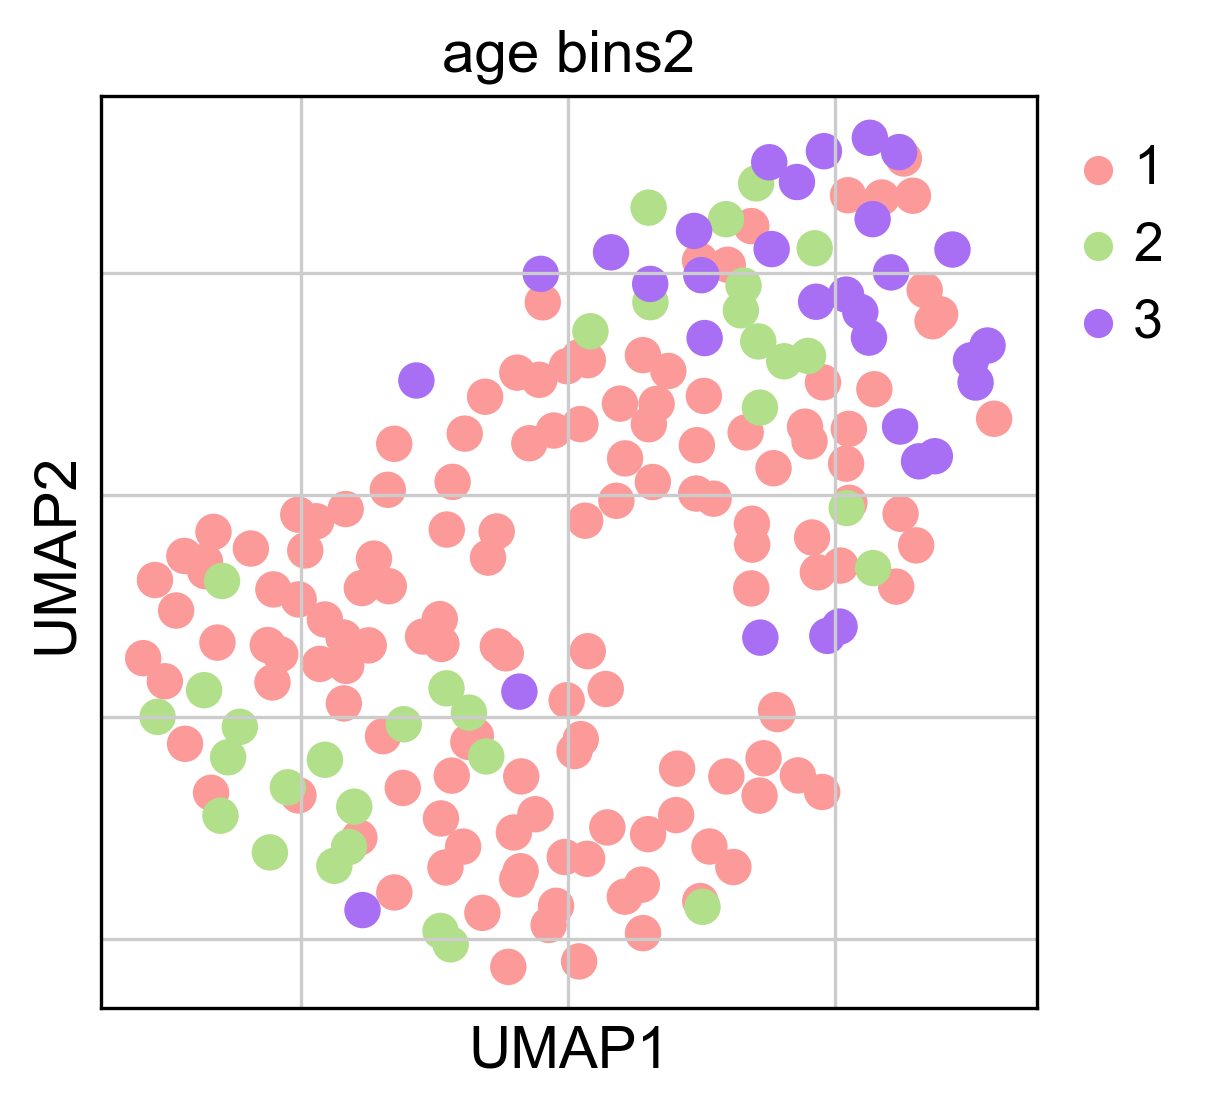

In [39]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
scv.pl.umap(adata_new_hc,color="age_bins2",palette=["#FB9A99","#B2DF8A","#a86ef4"]
           ,frameon=True, save=data_dir+"figures/figure3/cochlea-HC_HUMAN_age.pdf")

#### FIGURE 3b

In [16]:
scv.set_figure_params(figsize=(4,4))
import matplotlib.pyplot as plt

In [24]:
IHC=["OTOF","SLC17A8","SLC7A14","TBX2",'FGF8','MSX1','KCNMA1',]
OHC=["SLC26A5","OCM","KCNQ4","IKZF2",'BCL11B','DNM3','ATP2B2',]
HC=['MYO7A','TMC1','ATOH1','SOX2','INSM1','ATP2B2',]

In [28]:
adata_new=sc.read('human_cochlea_annotation_add_40000genes.h5ad')

In [29]:
adata_new_hc=adata_new[adata_new_HC_v3.obs.index]
adata_new_hc

View of AnnData object with n_obs × n_vars = 203 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'me

In [30]:
#adata_new.layers['counts']=adata_integration.layers['counts']
adata=adata_new_HC_v3.copy()
adata_new_hc.obsp['connectivities']=adata.obsp['connectivities']
adata_new_hc.obsp['distances']=adata.obsp['distances']

adata_new_hc.obsm['X_pca']=adata.obsm['X_pca']
adata_new_hc.obsm['X_scANVI']=adata.obsm['X_scANVI']
adata_new_hc.obsm['X_scVI']=adata.obsm['X_scVI']
adata_new_hc.obsm['X_umap']=adata.obsm['X_umap']
adata_new_hc.obsm['_scvi_extra_categorical_covs']=adata.obsm['_scvi_extra_categorical_covs']
adata_new_hc.obsm['_scvi_extra_continuous_covs']=adata.obsm['_scvi_extra_continuous_covs']

adata_new_hc.uns['_scvi_manager_uuid']=adata.uns['_scvi_manager_uuid']
adata_new_hc.uns['_scvi_uuid']=adata.uns['_scvi_uuid']
adata_new_hc.uns['annotation_colors']=adata.uns['annotation_colors']
adata_new_hc.uns['ccgs']=adata.uns['ccgs']
adata_new_hc.uns['cell_type_final_colors']=adata.uns['cell_type_final_colors']
adata_new_hc.uns['cell_type_final_v4_colors']=adata.uns['cell_type_final_v4_colors']
adata_new_hc.uns['hvg']=adata.uns['hvg']
adata_new_hc.uns['rank_genes_groups']=adata.uns['rank_genes_groups']
adata_new_hc.uns['log1p']=adata.uns['log1p']
adata_new_hc.uns['neighbors']=adata.uns['neighbors']
adata_new_hc.uns['sample_colors']=adata.uns['sample_colors']
adata_new_hc.uns['umap']=adata.uns['umap']
adata_new_hc.obs['cell_type_final']=adata.obs['cell_type_final']
adata_new_hc.obs['cell_type_final_v4']=adata.obs['cell_type_final_v4']
adata_new_hc.obs['low_ncounts']=adata.obs['low_ncounts']
adata_new_hc.obs['low_ncounts_high_mito']=adata.obs['low_ncounts_high_mito']
adata_new_hc.obs['S_score']=adata.obs['S_score']
adata_new_hc.obs['G2M_score']=adata.obs['G2M_score']
adata_new_hc.obs['phase']=adata.obs['phase']
adata_new_hc.obs['scrublet_score']=adata.obs['scrublet_score']
adata_new_hc.obs['scrublet_cluster_score']=adata.obs['scrublet_cluster_score']
adata_new_hc.obs['zscore']=adata.obs['zscore']
adata_new_hc.obs['bh_pval']=adata.obs['bh_pval']
adata_new_hc.obs['bonf_pval']=adata.obs['bonf_pval']
adata_new_hc.obs['is_doublet']=adata.obs['is_doublet']
adata_new_hc.obs['is_doublet_scrub']=adata.obs['is_doublet_scrub']
adata_new_hc.obs['_scvi_batch']=adata.obs['_scvi_batch']
adata_new_hc.obs['_scvi_labels']=adata.obs['_scvi_labels']

In [31]:
adata_new_hc.write('human_prenatal_hc_final_v2.h5ad')

In [33]:
sc.pp.normalize_per_cell(adata_new_hc, counts_per_cell_after=1e4)
sc.pp.log1p(adata_new_hc)

Text(0.5, 1.0, 'OTOF')

Text(0.5, 1.0, 'SLC17A8')

Text(0.5, 1.0, 'SLC7A14')

Text(0.5, 1.0, 'TBX2')

Text(0.5, 1.0, 'FGF8')

Text(0.5, 1.0, 'MSX1')

Text(0.5, 1.0, 'KCNMA1')

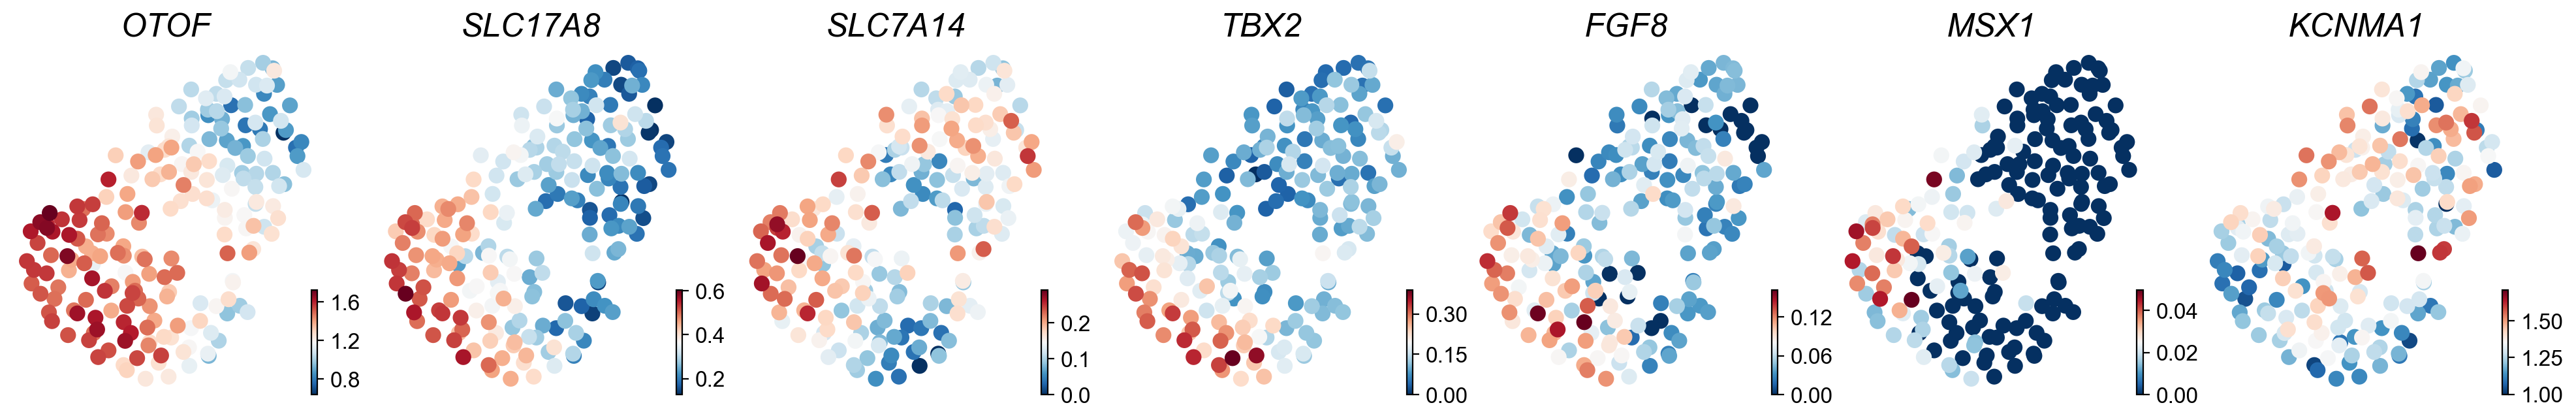

In [34]:
axs=scv.pl.umap(adata_new_hc,color=IHC,smooth=True,show=False,)
for ax in axs:
    ax.set_title(ax.get_title(),style="italic",fontsize=18)
plt.savefig(data_dir+"figures/figure3/IHC_HUMAN_MARKERS.pdf",dpi=600)

Text(0.5, 1.0, 'SLC26A5')

Text(0.5, 1.0, 'OCM')

Text(0.5, 1.0, 'KCNQ4')

Text(0.5, 1.0, 'IKZF2')

Text(0.5, 1.0, 'BCL11B')

Text(0.5, 1.0, 'DNM3')

Text(0.5, 1.0, 'ATP2B2')

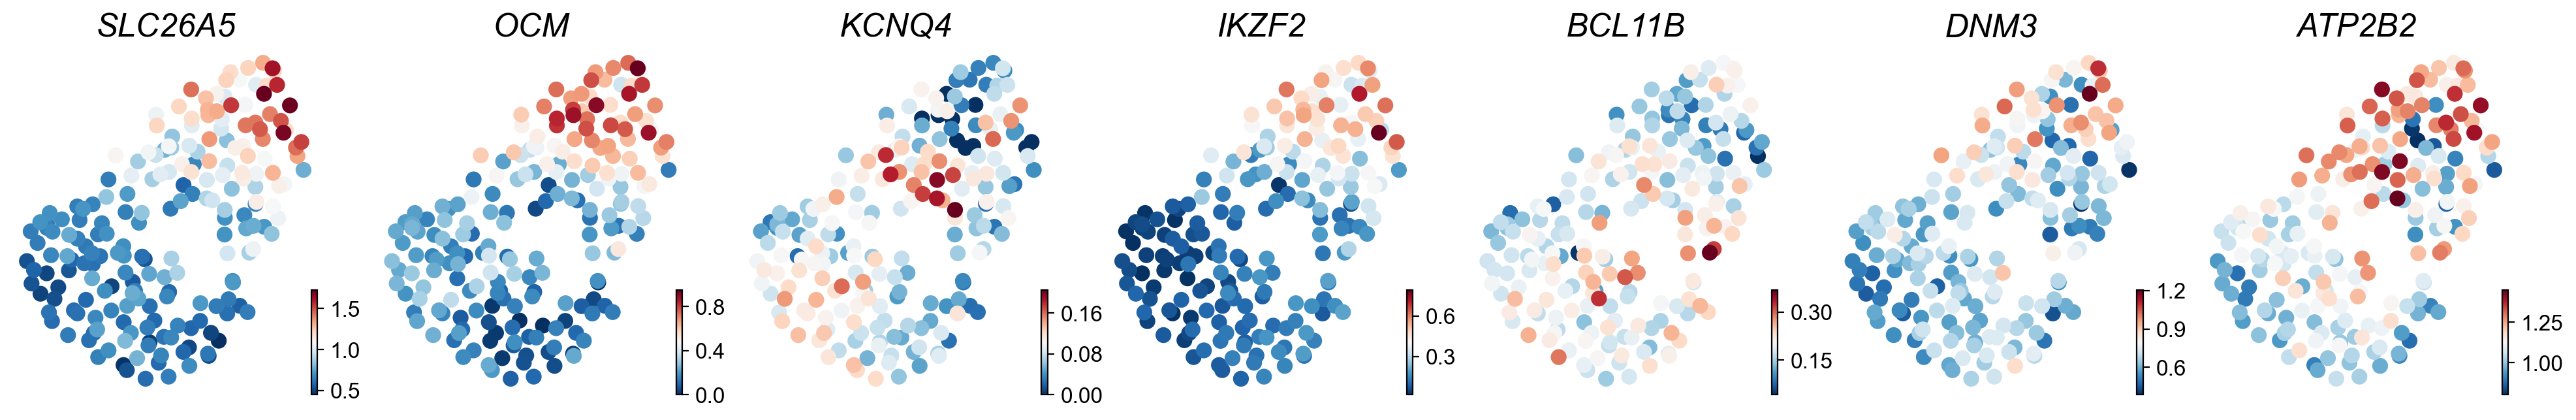

In [35]:
axs=scv.pl.umap(adata_new_hc,color=OHC,smooth=True,show=False,)
for ax in axs:
    ax.set_title(ax.get_title(),style="italic",fontsize=18)
plt.savefig(data_dir+"figures/figure3/OHC_HUMAN_MARKERS.pdf",dpi=600)

#### FIGURE 3d

In [40]:
genes=['TBX2','CASZ1','IKZF2','INSM1']

In [41]:
adata_new_hc.obs["cell_type_final_v4_age"] = (
    adata_new_hc.obs["cell_type_final_v4"].astype(str) + "_" + adata_new_hc.obs["age_bins2"].astype(str)
)

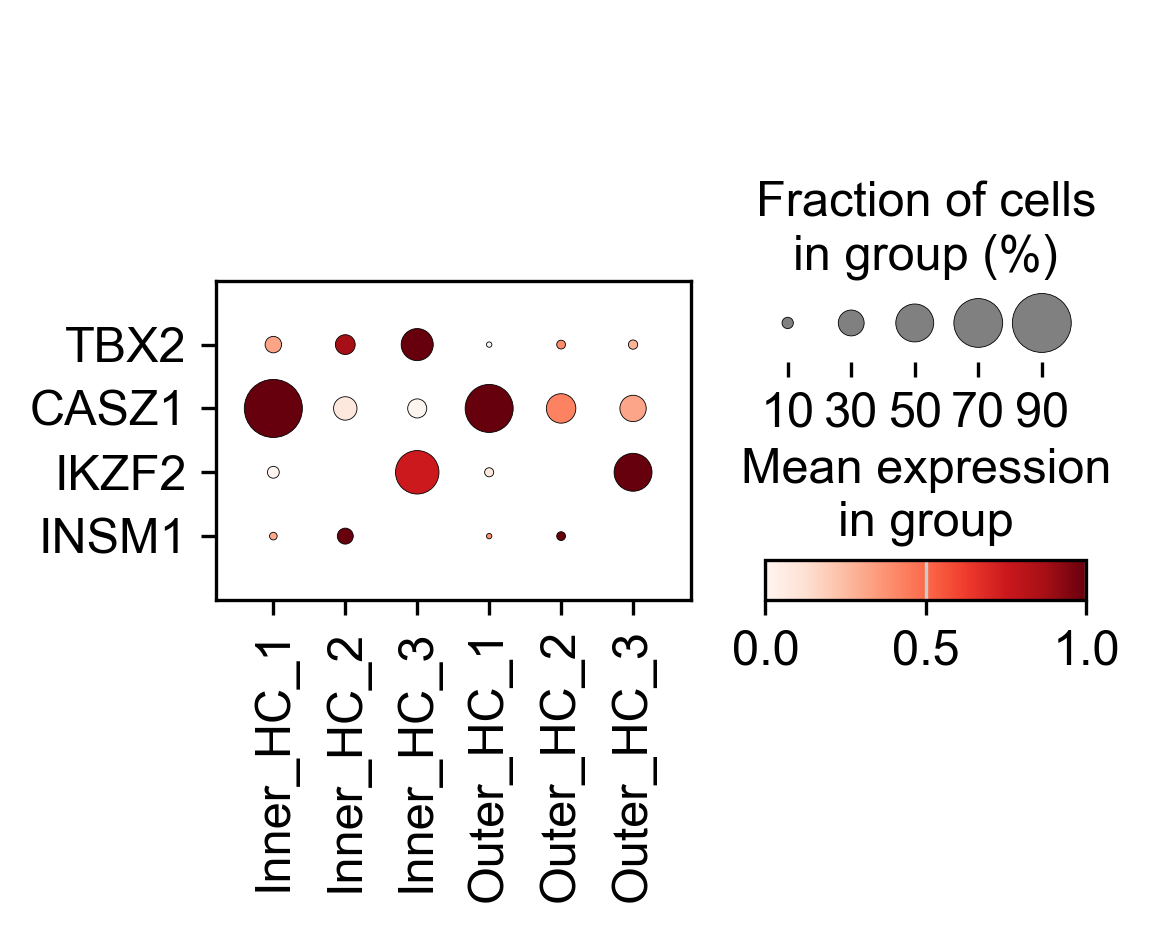

In [42]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(adata_new_hc, var_names=genes, groupby='cell_type_final_v4_age', swap_axes=True,
             save="_human_developmental_inner_hc3.pdf",standard_scale='var'
             )#standard_scale='var'